# Maintenance activity of tuned neurons

Do stimulus tuned neurons have different maintenance activity depending on if their preferred stimulus was shown

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import lfp_utils as lu
import rate_neuron_utils as rn
from bootstrap_method import *

2026-05-07 19:57:21.990300: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 19:57:21.999607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-07 19:57:22.008560: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-07 19:57:22.011280: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-07 19:57:22.018958: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 200
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_paths = ld.find_files(all_models_dir, '*N_1000*.mat')
model_names = [os.path.basename(m)[:-4] for m in model_paths]
print(len(model_names))
print(model_names)

8
['Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174533', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_17_155940', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_17_140925', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025058']


### visualize single model

In [4]:
# choose a model to visualize for now
model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

In [5]:
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

# behavioral data
trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

load_tuning = rn.calc_load_tuning(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_match",
                                all_models_dir=all_models_dir)

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']

(536, 1000, 450)


Neurons that prefer stim1=0 and maint=nan: 52


/tmp/ipykernel_764339/3369496589.py:59: RuntimeWarning: Mean of empty slice
  stim3_pref_mean = np.nanmean(neuron_rates[stim3_pref_load3_idx, :], axis=0)
/tmp/ipykernel_764339/3369496589.py:60: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  stim3_pref_sem = scipy.stats.sem(neuron_rates[stim3_pref_load3_idx, :], axis=0, nan_policy='omit')
/tmp/ipykernel_764339/3369496589.py:61: RuntimeWarning: Mean of empty slice
  stim2_pref_mean = np.nanmean(neuron_rates[stim2_pref_load3_idx, :], axis=0)
/tmp/ipykernel_764339/3369496589.py:62: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  stim2_pref_sem = scipy.stats.sem(neuron_rates[stim2_pref_load3_idx, :], axis=0, n

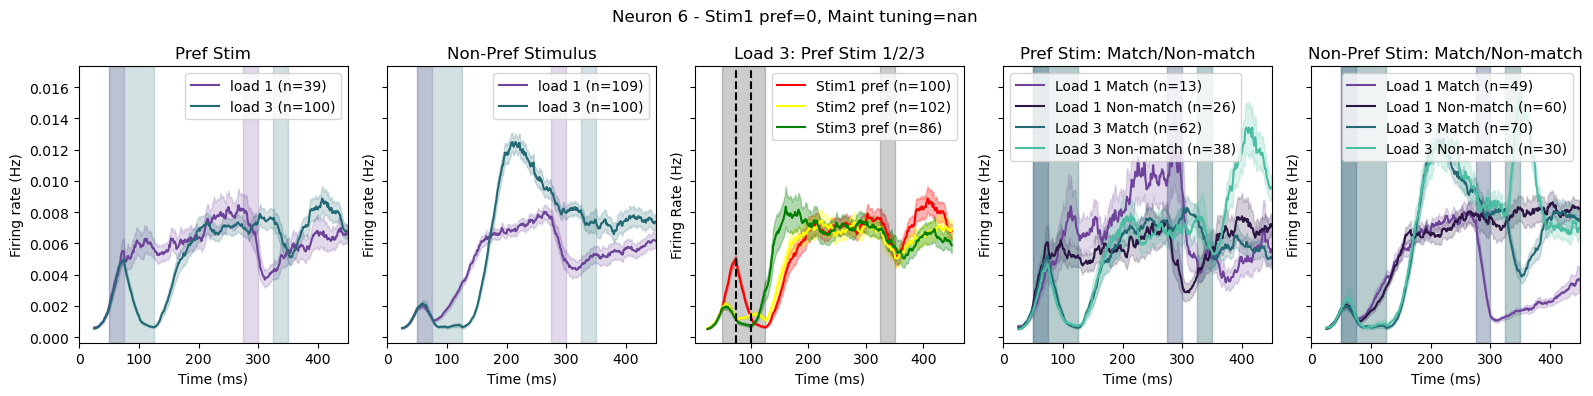

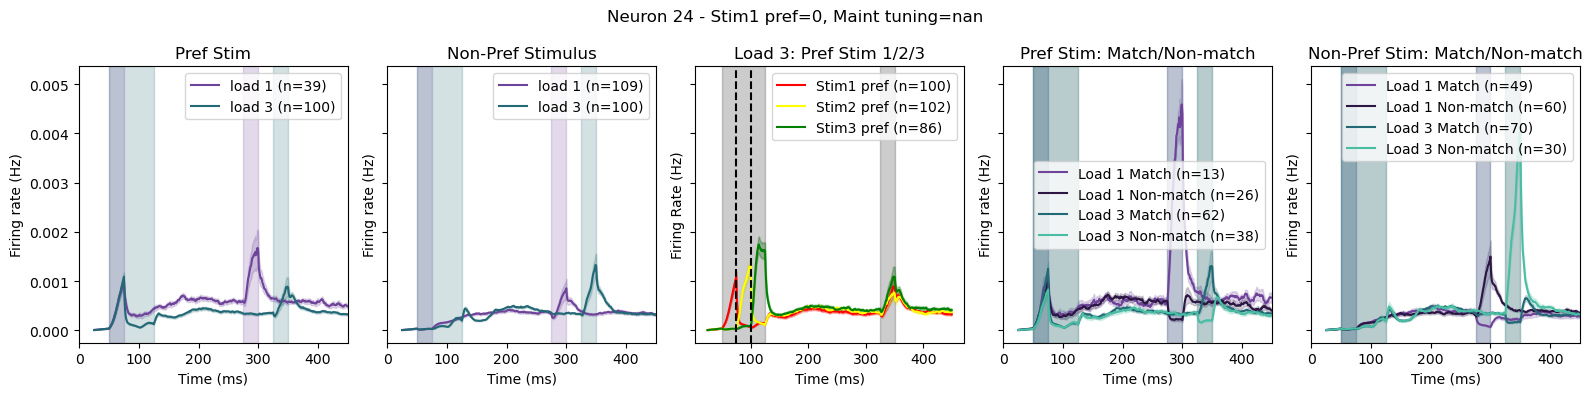

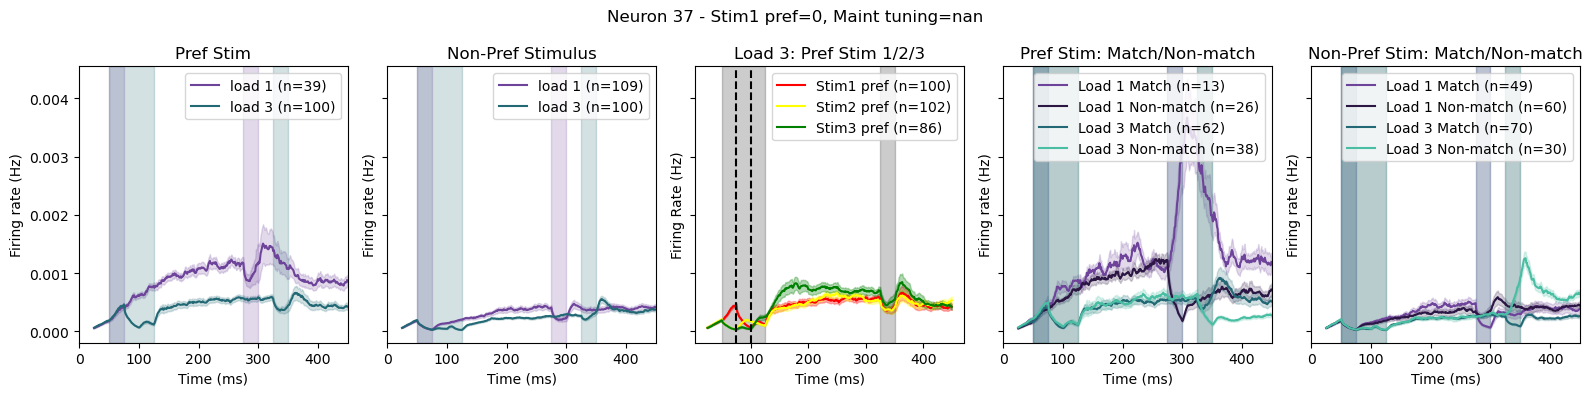

In [41]:
# let's start with neurons tuned to stim1=0
importlib.reload(rn)

stim1_pref = 0
maint_pref = np.nan

stim1_tuned_neurons = np.where(stim1_tuning == stim1_pref)[0]
if np.isnan(maint_pref):
    maint_tuned_neurons = np.where(np.isnan(load_tuning))[0] # no maintenance tuning
else:
    maint_tuned_neurons = np.where(load_tuning == maint_pref)[0]
# print(f'Neurons pref stim1={stim1_pref}: {len(stim1_tuned_neurons)}')
# print(f'Neurons pref maint={maint_pref}: {len(maint_tuned_neurons)}')

# for one of these neurons
neuron_idxs = np.intersect1d(stim1_tuned_neurons, maint_tuned_neurons)
print(f'Neurons that prefer stim1={stim1_pref} and maint={maint_pref}: {len(neuron_idxs)}')

for i_plot in range(3):

    neuron_idx = neuron_idxs[i_plot]
    neuron_rates = rates_data[:, neuron_idx, :]
    neuron_rates[:, :25] = np.nan # mask the first 25 time bins to avoid noise; trials x time

    _, colors = rn.get_trialtype_colors()

    t_range = np.arange(rates_data.shape[2])

    fig, axs = plt.subplots(1,5, figsize=(16,4), sharey=True)
    axs = axs.flatten()
    plt.suptitle(f'Neuron {neuron_idx} - Stim1 pref={stim1_pref}, Maint tuning={maint_pref}')

    #subplot1: stim1 = preferred, load 1 vs load 3
    if np.isnan(stim1_pref):
        print(f'Neuron {neuron_idx} is not significantly tuned to any stim1. Skipping subplot 1.')
        stim1_pref_load1_idx = np.array([], dtype=int)
        stim1_pref_load3_idx = np.array([], dtype=int)
    else:
        stim1_pref_load1_idx = np.where((trial_labels[:, 2] == stim1_pref) & (trial_labels[:, 0] == 1))[0]
        stim1_pref_load3_idx = np.where((trial_labels[:, 2] == stim1_pref) & (trial_labels[:, 0] == 3))[0]

        rn.plot_rates(neuron_rates, stim1_pref_load1_idx, stim1_pref_load3_idx, 
                    settings, trial_labels, title=f'Pref Stim', 
                    labels_one = 'load 1', labels_two = 'load 3', ax=axs[0], colors=None)


    # subplot2: stim1 = nonpreferred, load 1 vs load 3
    nonpref_idx = np.where(np.all(trial_labels[:, 2:5] != stim1_pref, axis=1))[0]
    nonpref_load1_idx = np.intersect1d(nonpref_idx, np.where(trial_labels[:, 0] == 1)[0])
    nonpref_load3_idx = np.intersect1d(nonpref_idx, np.where(trial_labels[:, 0] == 3)[0])
    rn.plot_rates(neuron_rates, nonpref_load1_idx, nonpref_load3_idx,
                settings, trial_labels, title='Non-Pref Stimulus', 
                labels_one = 'load 1', labels_two = 'load 3', ax=axs[1], colors=None)

    # subplot3: load 3-- preferred as stim1 vs stim2 vs stim3
    stim1_pref_load3_idx = np.where((trial_labels[:, 2] == stim1_pref) & (trial_labels[:, 0] == 3))[0]
    stim2_pref_load3_idx = np.where((trial_labels[:, 3] == stim1_pref) & (trial_labels[:, 0] == 3))[0]
    stim3_pref_load3_idx = np.where((trial_labels[:, 4] == stim1_pref) & (trial_labels[:, 0] == 3))[0]
    stim3_pref_mean = np.nanmean(neuron_rates[stim3_pref_load3_idx, :], axis=0)
    stim3_pref_sem = scipy.stats.sem(neuron_rates[stim3_pref_load3_idx, :], axis=0, nan_policy='omit')
    stim2_pref_mean = np.nanmean(neuron_rates[stim2_pref_load3_idx, :], axis=0)
    stim2_pref_sem = scipy.stats.sem(neuron_rates[stim2_pref_load3_idx, :], axis=0, nan_policy='omit')
    stim1_pref_mean = np.nanmean(neuron_rates[stim1_pref_load3_idx, :], axis=0)
    stim1_pref_sem = scipy.stats.sem(neuron_rates[stim1_pref_load3_idx, :], axis=0, nan_policy='omit')
    axs[2].plot(t_range, stim1_pref_mean, color='r', label=f'Stim1 pref (n={len(stim1_pref_load3_idx)})')
    axs[2].fill_between(t_range, stim1_pref_mean - stim1_pref_sem, stim1_pref_mean + stim1_pref_sem, color='r', alpha=0.3)  
    axs[2].plot(t_range, stim2_pref_mean, color='yellow', label=f'Stim2 pref (n={len(stim2_pref_load3_idx)})')
    axs[2].fill_between(t_range, stim2_pref_mean - stim2_pref_sem, stim2_pref_mean + stim2_pref_sem, color='yellow', alpha=0.3)
    axs[2].plot(t_range, stim3_pref_mean, color='g', label=f'Stim3 pref (n={len(stim3_pref_load3_idx)})')
    axs[2].fill_between(t_range, stim3_pref_mean - stim3_pref_sem, stim3_pref_mean + stim3_pref_sem, color='g', alpha=0.3)
    axs[2].axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*3, color='k', alpha=0.2)
    axs[2].axvspan(settings['stim_on'] + settings['stim_dur']*3 + settings['delay'], settings['stim_on'] + settings['stim_dur']*3 + settings['delay'] + settings['stim_dur'], color='k', alpha=0.2)
    axs[2].axvline(settings['stim_on'] + settings['stim_dur']*2, color='k', linestyle='--')
    axs[2].axvline(settings['stim_on'] + settings['stim_dur']*1, color='k', linestyle='--')
    axs[2].legend()
    axs[2].set_title('Load 3: Pref Stim 1/2/3')
    axs[2].set_xlabel('Time (ms)'); axs[2].set_ylabel('Firing Rate (Hz)')
    
    # subplot4: stim1=preferred, stim2=match vs non-match (only load 1 and 3)
    stim1_pref_load1_idx_match = np.intersect1d(stim1_pref_load1_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    stim1_pref_load1_idx_nonmatch = np.intersect1d(stim1_pref_load1_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    stim1_pref_load3_idx_match = np.intersect1d(stim1_pref_load3_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    stim1_pref_load3_idx_nonmatch = np.intersect1d(stim1_pref_load3_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    rn.plot_rates(neuron_rates, stim1_pref_load1_idx_match, stim1_pref_load1_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 1 Match', labels_two='Load 1 Non-match', colors=[colors[0],colors[1]], ax=axs[3],
                  title='Pref Stim: Match/Non-match')
    rn.plot_rates(neuron_rates, stim1_pref_load3_idx_match, stim1_pref_load3_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 3 Match', labels_two='Load 3 Non-match', colors=[colors[2],colors[3]], ax=axs[3],
                  title='Pref Stim: Match/Non-match')
    
    # subplot5: stim1=nonpreferred, stim2=match vs non-match (only load 1 and 3)
    nonpref_load1_idx_match = np.intersect1d(nonpref_load1_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    nonpref_load1_idx_nonmatch = np.intersect1d(nonpref_load1_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    nonpref_load3_idx_match = np.intersect1d(nonpref_load3_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    nonpref_load3_idx_nonmatch = np.intersect1d(nonpref_load3_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    rn.plot_rates(neuron_rates, nonpref_load1_idx_match, nonpref_load1_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 1 Match', labels_two='Load 1 Non-match', colors=[colors[0],colors[1]], ax=axs[4],
                  title='Non-Pref Stim: Match/Non-match')
    rn.plot_rates(neuron_rates, nonpref_load3_idx_match, nonpref_load3_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 3 Match', labels_two='Load 3 Non-match', colors=[colors[2],colors[3]], ax=axs[4],
                  title='Non-Pref Stim: Match/Non-match')

    plt.tight_layout()
    plt.show()

Neurons that prefer stim1=0 and maint=1: 10


/tmp/ipykernel_764339/3062239942.py:58: RuntimeWarning: Mean of empty slice
  stim3_pref_mean = np.nanmean(neuron_rates[stim3_pref_load3_idx, :], axis=0)
/tmp/ipykernel_764339/3062239942.py:59: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  stim3_pref_sem = scipy.stats.sem(neuron_rates[stim3_pref_load3_idx, :], axis=0, nan_policy='omit')
/tmp/ipykernel_764339/3062239942.py:60: RuntimeWarning: Mean of empty slice
  stim2_pref_mean = np.nanmean(neuron_rates[stim2_pref_load3_idx, :], axis=0)
/tmp/ipykernel_764339/3062239942.py:61: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  stim2_pref_sem = scipy.stats.sem(neuron_rates[stim2_pref_load3_idx, :], axis=0, n

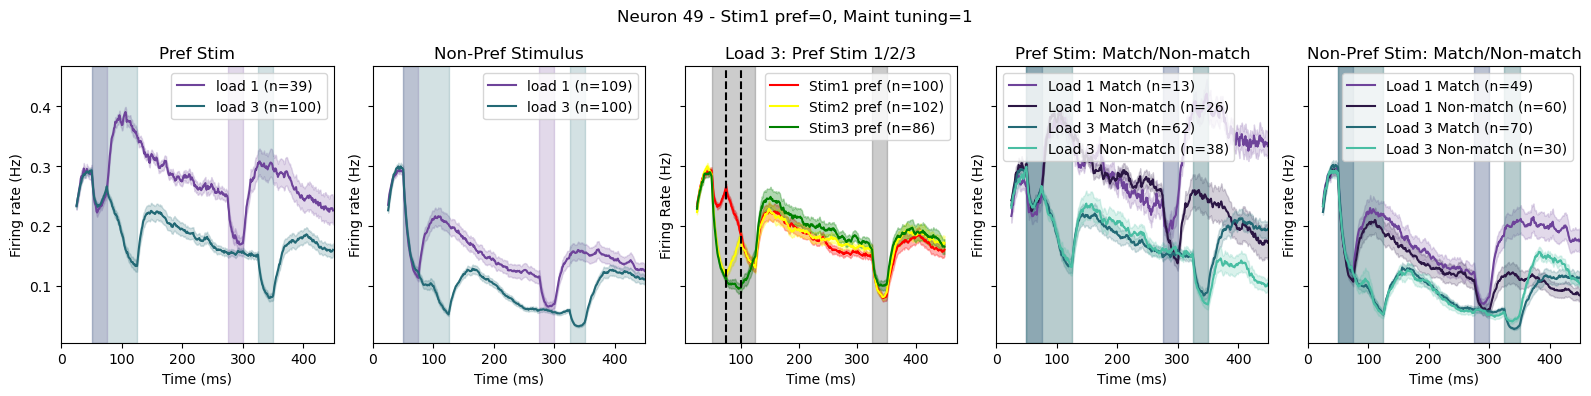

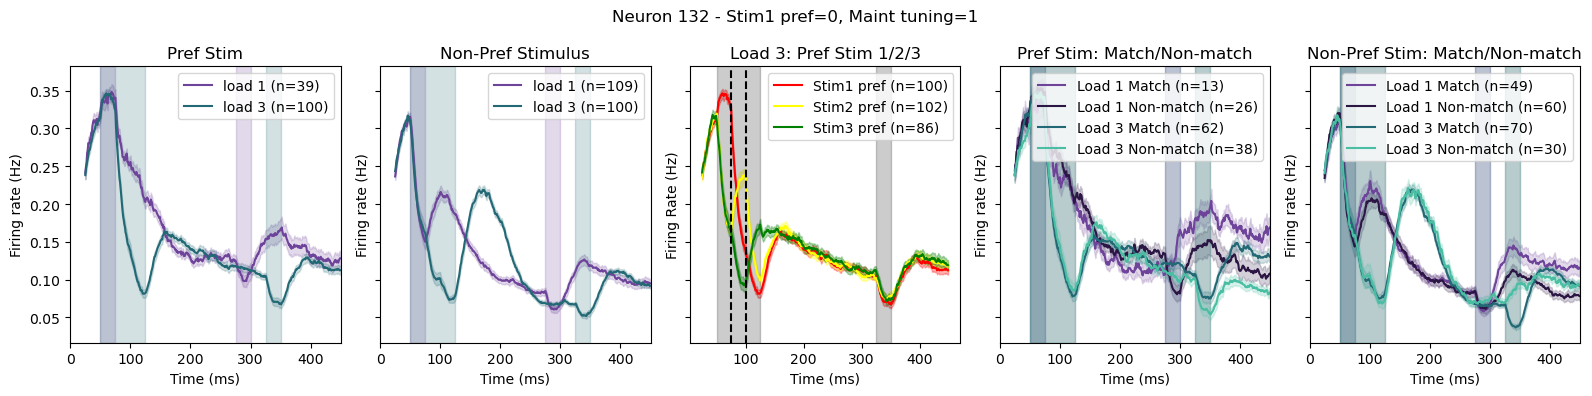

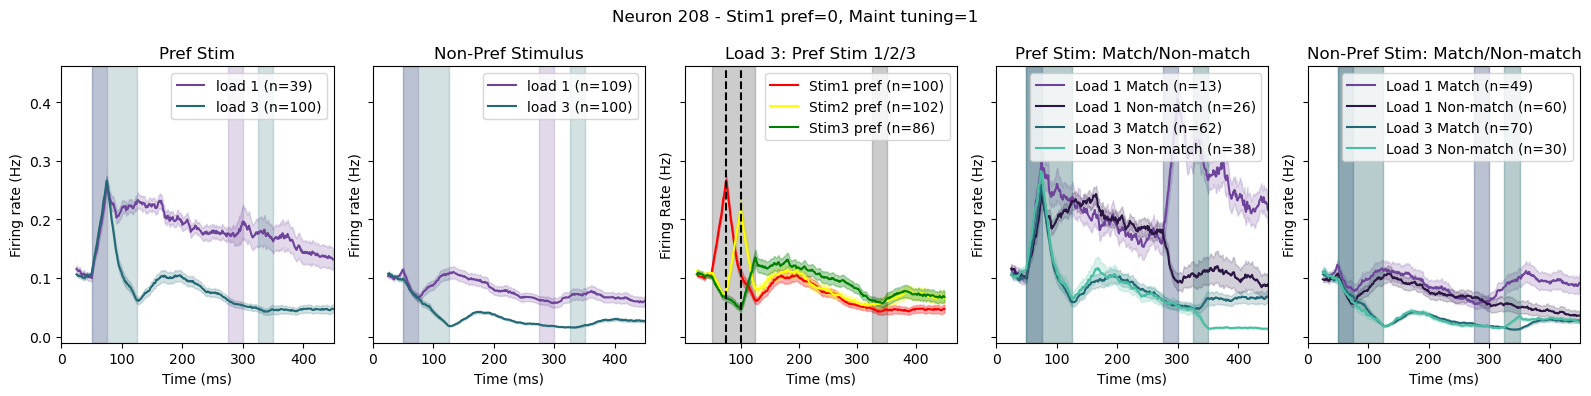

In [40]:
# let's start with neurons tuned to stim1=0
importlib.reload(rn)

stim1_pref = 0
maint_pref = 1

stim1_tuned_neurons = np.where(stim1_tuning == stim1_pref)[0]
if np.isnan(maint_pref):
    maint_tuned_neurons = np.where(np.isnan(load_tuning))[0] # no maintenance tuning
else:
    maint_tuned_neurons = np.where(load_tuning == maint_pref)[0]
# print(f'Neurons pref stim1={stim1_pref}: {len(stim1_tuned_neurons)}')
# print(f'Neurons pref maint={maint_pref}: {len(maint_tuned_neurons)}')

# for one of these neurons
neuron_idxs = np.intersect1d(stim1_tuned_neurons, maint_tuned_neurons)
print(f'Neurons that prefer stim1={stim1_pref} and maint={maint_pref}: {len(neuron_idxs)}')

for i_plot in range(3):
    neuron_idx = neuron_idxs[i_plot]
    neuron_rates = rates_data[:, neuron_idx, :]
    neuron_rates[:, :25] = np.nan # mask the first 25 time bins to avoid noise; trials x time

    _, colors = rn.get_trialtype_colors()

    t_range = np.arange(rates_data.shape[2])

    fig, axs = plt.subplots(1,5, figsize=(16,4), sharey=True)
    axs = axs.flatten()
    plt.suptitle(f'Neuron {neuron_idx} - Stim1 pref={stim1_pref}, Maint tuning={maint_pref}')

    #subplot1: stim1 = preferred, load 1 vs load 3
    if np.isnan(stim1_pref):
        print(f'Neuron {neuron_idx} is not significantly tuned to any stim1. Skipping subplot 1.')
        stim1_pref_load1_idx = np.array([], dtype=int)
        stim1_pref_load3_idx = np.array([], dtype=int)
    else:
        stim1_pref_load1_idx = np.where((trial_labels[:, 2] == stim1_pref) & (trial_labels[:, 0] == 1))[0]
        stim1_pref_load3_idx = np.where((trial_labels[:, 2] == stim1_pref) & (trial_labels[:, 0] == 3))[0]

        rn.plot_rates(neuron_rates, stim1_pref_load1_idx, stim1_pref_load3_idx, 
                    settings, trial_labels, title=f'Pref Stim', 
                    labels_one = 'load 1', labels_two = 'load 3', ax=axs[0], colors=None)


    # subplot2: stim1 = nonpreferred, load 1 vs load 3
    nonpref_idx = np.where(np.all(trial_labels[:, 2:5] != stim1_pref, axis=1))[0]
    nonpref_load1_idx = np.intersect1d(nonpref_idx, np.where(trial_labels[:, 0] == 1)[0])
    nonpref_load3_idx = np.intersect1d(nonpref_idx, np.where(trial_labels[:, 0] == 3)[0])
    rn.plot_rates(neuron_rates, nonpref_load1_idx, nonpref_load3_idx,
                settings, trial_labels, title='Non-Pref Stimulus', 
                labels_one = 'load 1', labels_two = 'load 3', ax=axs[1], colors=None)

    # subplot3: load 3-- preferred as stim1 vs stim2 vs stim3
    stim1_pref_load3_idx = np.where((trial_labels[:, 2] == stim1_pref) & (trial_labels[:, 0] == 3))[0]
    stim2_pref_load3_idx = np.where((trial_labels[:, 3] == stim1_pref) & (trial_labels[:, 0] == 3))[0]
    stim3_pref_load3_idx = np.where((trial_labels[:, 4] == stim1_pref) & (trial_labels[:, 0] == 3))[0]
    stim3_pref_mean = np.nanmean(neuron_rates[stim3_pref_load3_idx, :], axis=0)
    stim3_pref_sem = scipy.stats.sem(neuron_rates[stim3_pref_load3_idx, :], axis=0, nan_policy='omit')
    stim2_pref_mean = np.nanmean(neuron_rates[stim2_pref_load3_idx, :], axis=0)
    stim2_pref_sem = scipy.stats.sem(neuron_rates[stim2_pref_load3_idx, :], axis=0, nan_policy='omit')
    stim1_pref_mean = np.nanmean(neuron_rates[stim1_pref_load3_idx, :], axis=0)
    stim1_pref_sem = scipy.stats.sem(neuron_rates[stim1_pref_load3_idx, :], axis=0, nan_policy='omit')
    axs[2].plot(t_range, stim1_pref_mean, color='r', label=f'Stim1 pref (n={len(stim1_pref_load3_idx)})')
    axs[2].fill_between(t_range, stim1_pref_mean - stim1_pref_sem, stim1_pref_mean + stim1_pref_sem, color='r', alpha=0.3)  
    axs[2].plot(t_range, stim2_pref_mean, color='yellow', label=f'Stim2 pref (n={len(stim2_pref_load3_idx)})')
    axs[2].fill_between(t_range, stim2_pref_mean - stim2_pref_sem, stim2_pref_mean + stim2_pref_sem, color='yellow', alpha=0.3)
    axs[2].plot(t_range, stim3_pref_mean, color='g', label=f'Stim3 pref (n={len(stim3_pref_load3_idx)})')
    axs[2].fill_between(t_range, stim3_pref_mean - stim3_pref_sem, stim3_pref_mean + stim3_pref_sem, color='g', alpha=0.3)
    axs[2].axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*3, color='k', alpha=0.2)
    axs[2].axvspan(settings['stim_on'] + settings['stim_dur']*3 + settings['delay'], settings['stim_on'] + settings['stim_dur']*3 + settings['delay'] + settings['stim_dur'], color='k', alpha=0.2)
    axs[2].axvline(settings['stim_on'] + settings['stim_dur']*2, color='k', linestyle='--')
    axs[2].axvline(settings['stim_on'] + settings['stim_dur']*1, color='k', linestyle='--')
    axs[2].legend()
    axs[2].set_title('Load 3: Pref Stim 1/2/3')
    axs[2].set_xlabel('Time (ms)'); axs[2].set_ylabel('Firing Rate (Hz)')
    
    # subplot4: stim1=preferred, stim2=match vs non-match (only load 1 and 3)
    stim1_pref_load1_idx_match = np.intersect1d(stim1_pref_load1_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    stim1_pref_load1_idx_nonmatch = np.intersect1d(stim1_pref_load1_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    stim1_pref_load3_idx_match = np.intersect1d(stim1_pref_load3_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    stim1_pref_load3_idx_nonmatch = np.intersect1d(stim1_pref_load3_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    rn.plot_rates(neuron_rates, stim1_pref_load1_idx_match, stim1_pref_load1_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 1 Match', labels_two='Load 1 Non-match', colors=[colors[0],colors[1]], ax=axs[3],
                  title='Pref Stim: Match/Non-match')
    rn.plot_rates(neuron_rates, stim1_pref_load3_idx_match, stim1_pref_load3_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 3 Match', labels_two='Load 3 Non-match', colors=[colors[2],colors[3]], ax=axs[3],
                  title='Pref Stim: Match/Non-match')
    
    # subplot5: stim1=nonpreferred, stim2=match vs non-match (only load 1 and 3)
    nonpref_load1_idx_match = np.intersect1d(nonpref_load1_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    nonpref_load1_idx_nonmatch = np.intersect1d(nonpref_load1_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    nonpref_load3_idx_match = np.intersect1d(nonpref_load3_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    nonpref_load3_idx_nonmatch = np.intersect1d(nonpref_load3_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    rn.plot_rates(neuron_rates, nonpref_load1_idx_match, nonpref_load1_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 1 Match', labels_two='Load 1 Non-match', colors=[colors[0],colors[1]], ax=axs[4],
                  title='Non-Pref Stim: Match/Non-match')
    rn.plot_rates(neuron_rates, nonpref_load3_idx_match, nonpref_load3_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 3 Match', labels_two='Load 3 Non-match', colors=[colors[2],colors[3]], ax=axs[4],
                  title='Non-Pref Stim: Match/Non-match')

    plt.tight_layout()
    plt.show()

Neurons that prefer stim1=0 and maint=3: 53


/tmp/ipykernel_764339/2007053515.py:58: RuntimeWarning: Mean of empty slice
  stim3_pref_mean = np.nanmean(neuron_rates[stim3_pref_load3_idx, :], axis=0)
/tmp/ipykernel_764339/2007053515.py:59: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  stim3_pref_sem = scipy.stats.sem(neuron_rates[stim3_pref_load3_idx, :], axis=0, nan_policy='omit')
/tmp/ipykernel_764339/2007053515.py:60: RuntimeWarning: Mean of empty slice
  stim2_pref_mean = np.nanmean(neuron_rates[stim2_pref_load3_idx, :], axis=0)
/tmp/ipykernel_764339/2007053515.py:61: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  stim2_pref_sem = scipy.stats.sem(neuron_rates[stim2_pref_load3_idx, :], axis=0, n

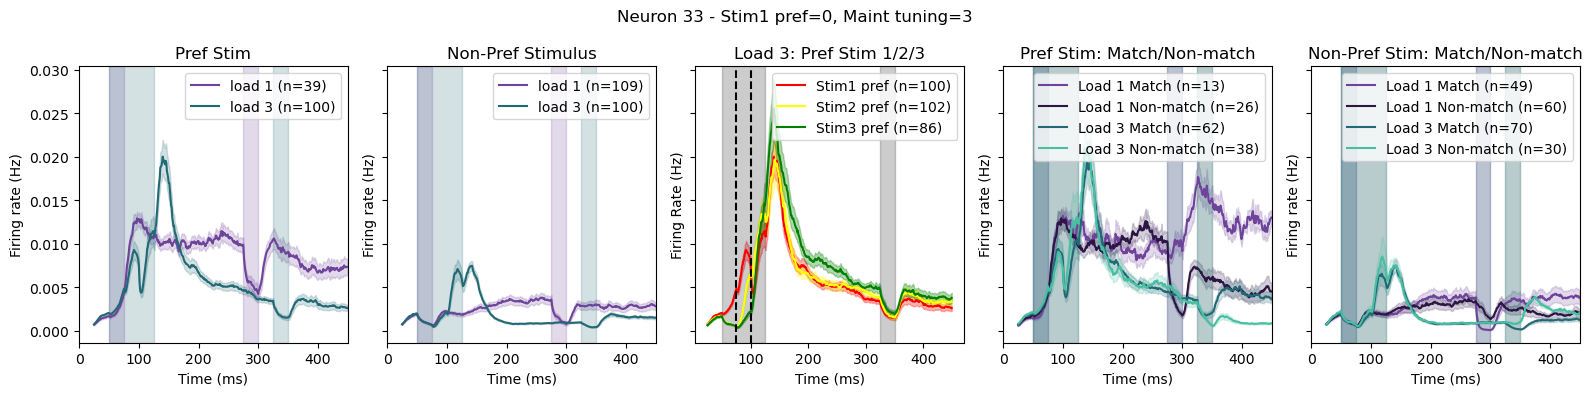

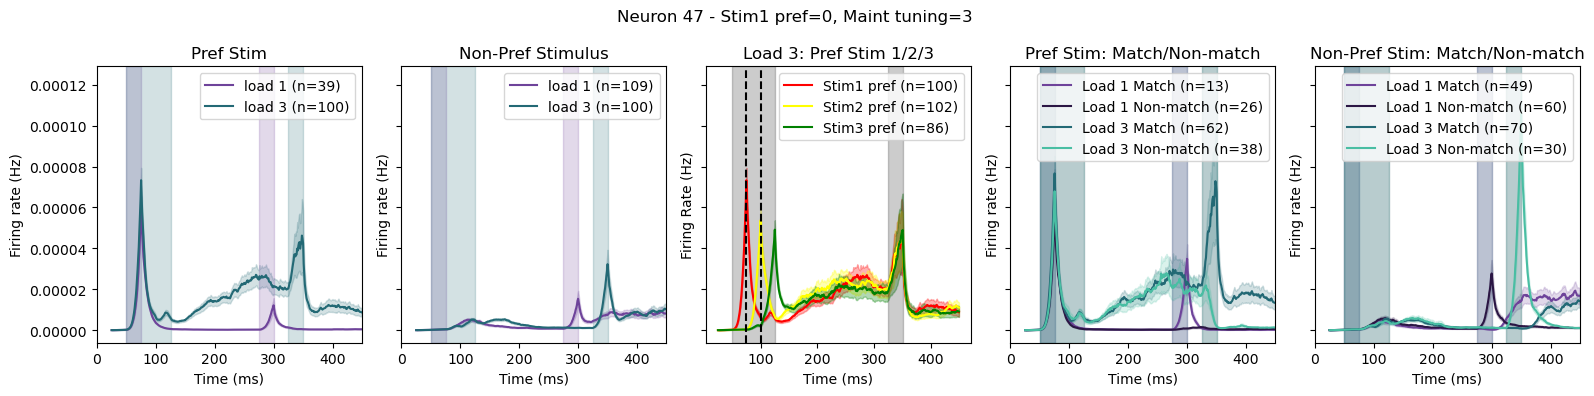

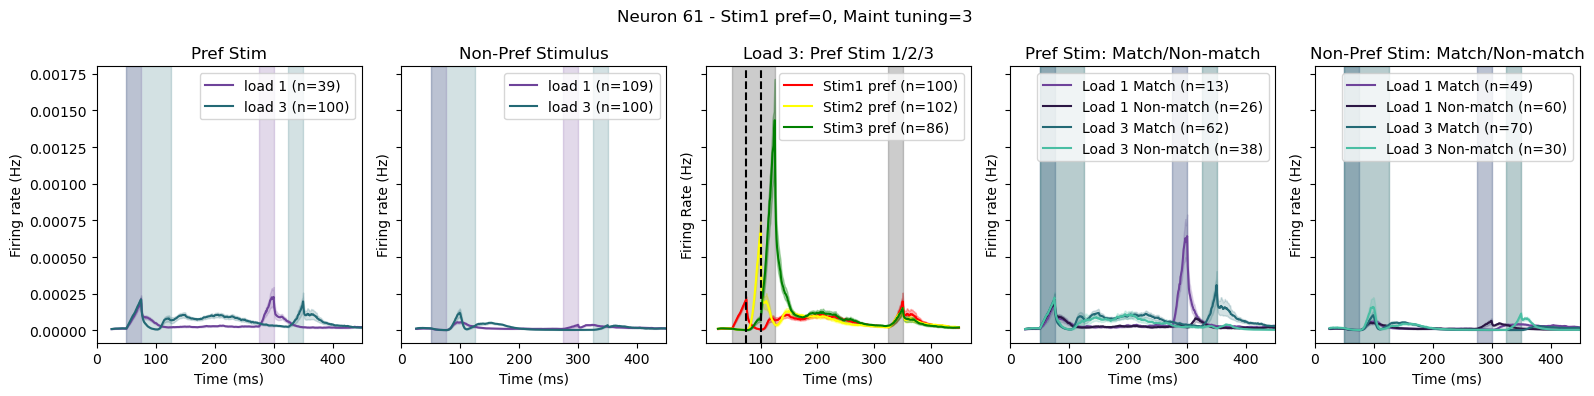

In [39]:
# let's start with neurons tuned to stim1=0
importlib.reload(rn)

stim1_pref = 0
maint_pref = 3

stim1_tuned_neurons = np.where(stim1_tuning == stim1_pref)[0]
if np.isnan(maint_pref):
    maint_tuned_neurons = np.where(np.isnan(load_tuning))[0] # no maintenance tuning
else:
    maint_tuned_neurons = np.where(load_tuning == maint_pref)[0]
# print(f'Neurons pref stim1={stim1_pref}: {len(stim1_tuned_neurons)}')
# print(f'Neurons pref maint={maint_pref}: {len(maint_tuned_neurons)}')

# for one of these neurons
neuron_idxs = np.intersect1d(stim1_tuned_neurons, maint_tuned_neurons)
print(f'Neurons that prefer stim1={stim1_pref} and maint={maint_pref}: {len(neuron_idxs)}')

for i_plot in range(3):
    neuron_idx = neuron_idxs[i_plot]
    neuron_rates = rates_data[:, neuron_idx, :]
    neuron_rates[:, :25] = np.nan # mask the first 25 time bins to avoid noise; trials x time

    _, colors = rn.get_trialtype_colors()

    t_range = np.arange(rates_data.shape[2])

    fig, axs = plt.subplots(1,5, figsize=(16,4), sharey=True)
    axs = axs.flatten()
    plt.suptitle(f'Neuron {neuron_idx} - Stim1 pref={stim1_pref}, Maint tuning={maint_pref}')

    #subplot1: stim1 = preferred, load 1 vs load 3
    if np.isnan(stim1_pref):
        print(f'Neuron {neuron_idx} is not significantly tuned to any stim1. Skipping subplot 1.')
        stim1_pref_load1_idx = np.array([], dtype=int)
        stim1_pref_load3_idx = np.array([], dtype=int)
    else:
        stim1_pref_load1_idx = np.where((trial_labels[:, 2] == stim1_pref) & (trial_labels[:, 0] == 1))[0]
        stim1_pref_load3_idx = np.where((trial_labels[:, 2] == stim1_pref) & (trial_labels[:, 0] == 3))[0]

        rn.plot_rates(neuron_rates, stim1_pref_load1_idx, stim1_pref_load3_idx, 
                    settings, trial_labels, title=f'Pref Stim', 
                    labels_one = 'load 1', labels_two = 'load 3', ax=axs[0], colors=None)


    # subplot2: stim1 = nonpreferred, load 1 vs load 3
    nonpref_idx = np.where(np.all(trial_labels[:, 2:5] != stim1_pref, axis=1))[0]
    nonpref_load1_idx = np.intersect1d(nonpref_idx, np.where(trial_labels[:, 0] == 1)[0])
    nonpref_load3_idx = np.intersect1d(nonpref_idx, np.where(trial_labels[:, 0] == 3)[0])
    rn.plot_rates(neuron_rates, nonpref_load1_idx, nonpref_load3_idx,
                settings, trial_labels, title='Non-Pref Stimulus', 
                labels_one = 'load 1', labels_two = 'load 3', ax=axs[1], colors=None)

    # subplot3: load 3-- preferred as stim1 vs stim2 vs stim3
    stim1_pref_load3_idx = np.where((trial_labels[:, 2] == stim1_pref) & (trial_labels[:, 0] == 3))[0]
    stim2_pref_load3_idx = np.where((trial_labels[:, 3] == stim1_pref) & (trial_labels[:, 0] == 3))[0]
    stim3_pref_load3_idx = np.where((trial_labels[:, 4] == stim1_pref) & (trial_labels[:, 0] == 3))[0]
    stim3_pref_mean = np.nanmean(neuron_rates[stim3_pref_load3_idx, :], axis=0)
    stim3_pref_sem = scipy.stats.sem(neuron_rates[stim3_pref_load3_idx, :], axis=0, nan_policy='omit')
    stim2_pref_mean = np.nanmean(neuron_rates[stim2_pref_load3_idx, :], axis=0)
    stim2_pref_sem = scipy.stats.sem(neuron_rates[stim2_pref_load3_idx, :], axis=0, nan_policy='omit')
    stim1_pref_mean = np.nanmean(neuron_rates[stim1_pref_load3_idx, :], axis=0)
    stim1_pref_sem = scipy.stats.sem(neuron_rates[stim1_pref_load3_idx, :], axis=0, nan_policy='omit')
    axs[2].plot(t_range, stim1_pref_mean, color='r', label=f'Stim1 pref (n={len(stim1_pref_load3_idx)})')
    axs[2].fill_between(t_range, stim1_pref_mean - stim1_pref_sem, stim1_pref_mean + stim1_pref_sem, color='r', alpha=0.3)  
    axs[2].plot(t_range, stim2_pref_mean, color='yellow', label=f'Stim2 pref (n={len(stim2_pref_load3_idx)})')
    axs[2].fill_between(t_range, stim2_pref_mean - stim2_pref_sem, stim2_pref_mean + stim2_pref_sem, color='yellow', alpha=0.3)
    axs[2].plot(t_range, stim3_pref_mean, color='g', label=f'Stim3 pref (n={len(stim3_pref_load3_idx)})')
    axs[2].fill_between(t_range, stim3_pref_mean - stim3_pref_sem, stim3_pref_mean + stim3_pref_sem, color='g', alpha=0.3)
    axs[2].axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*3, color='k', alpha=0.2)
    axs[2].axvspan(settings['stim_on'] + settings['stim_dur']*3 + settings['delay'], settings['stim_on'] + settings['stim_dur']*3 + settings['delay'] + settings['stim_dur'], color='k', alpha=0.2)
    axs[2].axvline(settings['stim_on'] + settings['stim_dur']*2, color='k', linestyle='--')
    axs[2].axvline(settings['stim_on'] + settings['stim_dur']*1, color='k', linestyle='--')
    axs[2].legend()
    axs[2].set_title('Load 3: Pref Stim 1/2/3')
    axs[2].set_xlabel('Time (ms)'); axs[2].set_ylabel('Firing Rate (Hz)')
    
    # subplot4: stim1=preferred, stim2=match vs non-match (only load 1 and 3)
    stim1_pref_load1_idx_match = np.intersect1d(stim1_pref_load1_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    stim1_pref_load1_idx_nonmatch = np.intersect1d(stim1_pref_load1_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    stim1_pref_load3_idx_match = np.intersect1d(stim1_pref_load3_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    stim1_pref_load3_idx_nonmatch = np.intersect1d(stim1_pref_load3_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    rn.plot_rates(neuron_rates, stim1_pref_load1_idx_match, stim1_pref_load1_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 1 Match', labels_two='Load 1 Non-match', colors=[colors[0],colors[1]], ax=axs[3],
                  title='Pref Stim: Match/Non-match')
    rn.plot_rates(neuron_rates, stim1_pref_load3_idx_match, stim1_pref_load3_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 3 Match', labels_two='Load 3 Non-match', colors=[colors[2],colors[3]], ax=axs[3],
                  title='Pref Stim: Match/Non-match')
    
    # subplot5: stim1=nonpreferred, stim2=match vs non-match (only load 1 and 3)
    nonpref_load1_idx_match = np.intersect1d(nonpref_load1_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    nonpref_load1_idx_nonmatch = np.intersect1d(nonpref_load1_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    nonpref_load3_idx_match = np.intersect1d(nonpref_load3_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    nonpref_load3_idx_nonmatch = np.intersect1d(nonpref_load3_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    rn.plot_rates(neuron_rates, nonpref_load1_idx_match, nonpref_load1_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 1 Match', labels_two='Load 1 Non-match', colors=[colors[0],colors[1]], ax=axs[4],
                  title='Non-Pref Stim: Match/Non-match')
    rn.plot_rates(neuron_rates, nonpref_load3_idx_match, nonpref_load3_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 3 Match', labels_two='Load 3 Non-match', colors=[colors[2],colors[3]], ax=axs[4],
                  title='Non-Pref Stim: Match/Non-match')

    plt.tight_layout()
    plt.show()

### load-tuned, but stim-untuned neurons

Neurons that prefer stim1=nan and maint=1: 18


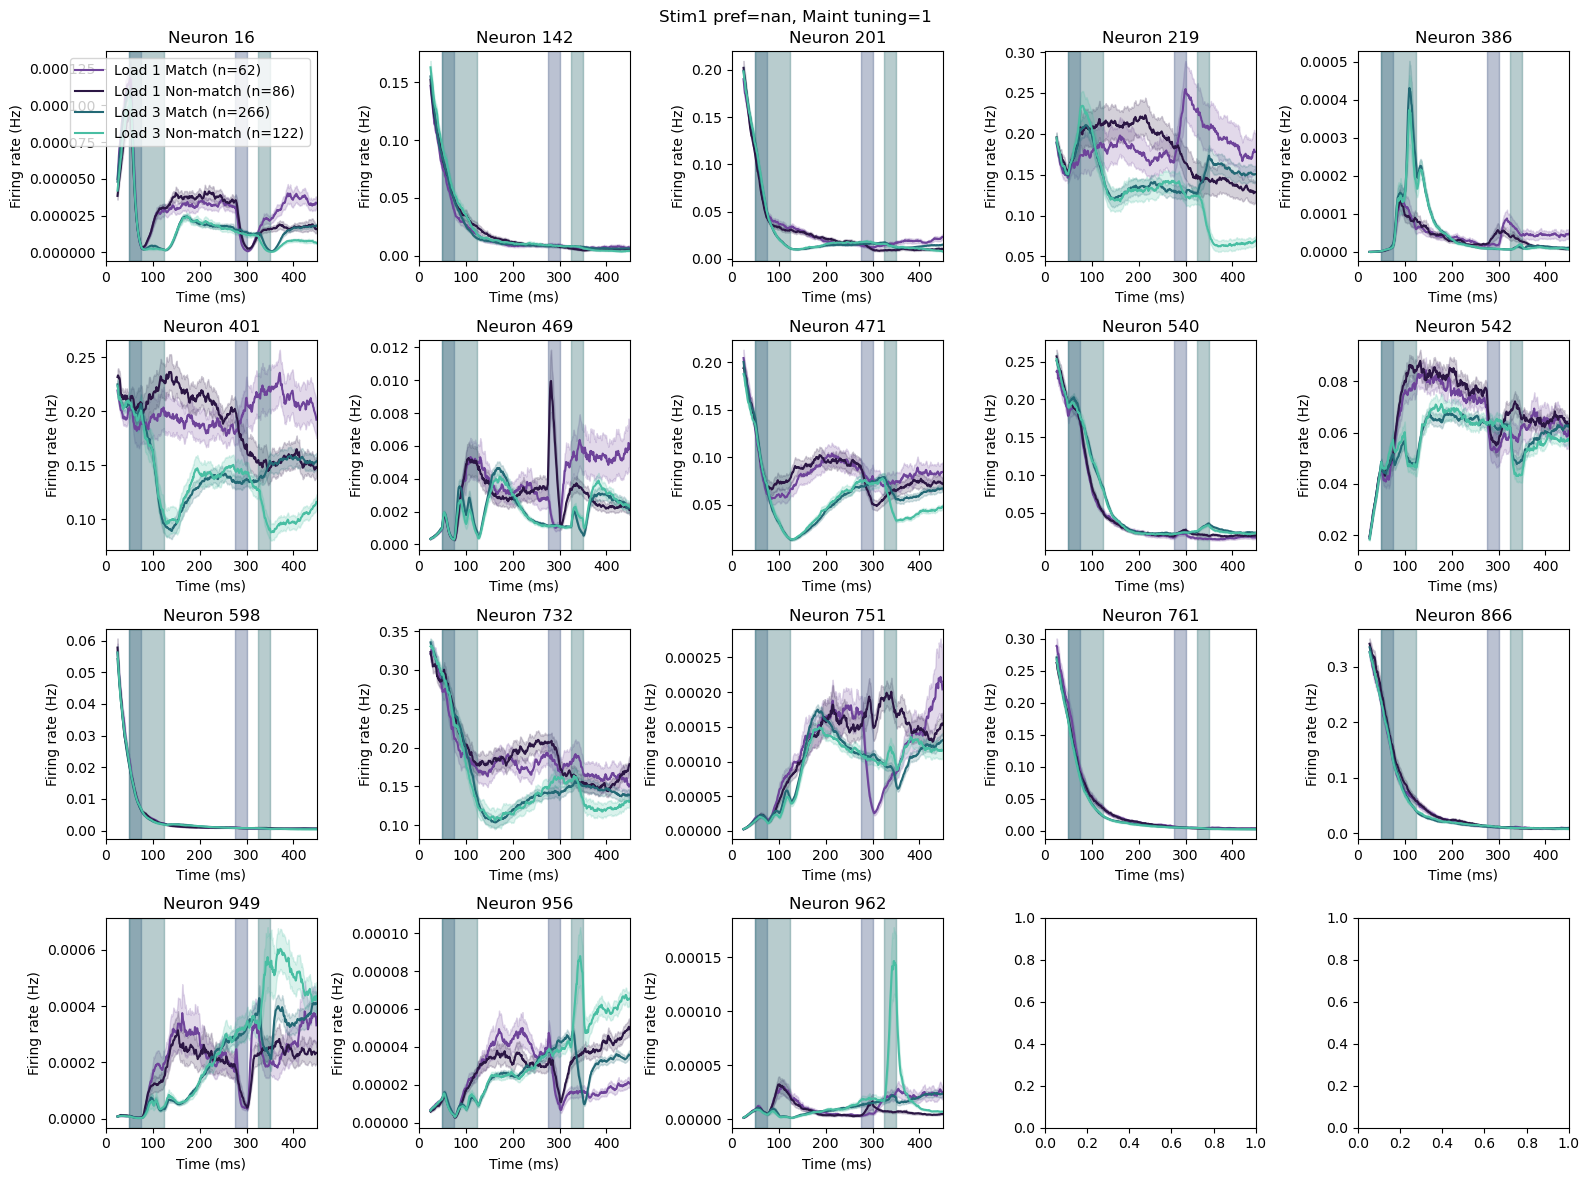

In [14]:
# let's start with neurons without tuning to stim1, pref load 1
importlib.reload(rn)

stim1_pref = np.nan
maint_pref = 1

if np.isnan(stim1_pref):
    stim1_tuned_neurons = np.where(np.isnan(stim1_tuning))[0] # no stim1 tuning
else:
    stim1_tuned_neurons = np.where(stim1_tuning == stim1_pref)[0]
if np.isnan(maint_pref):
    maint_tuned_neurons = np.where(np.isnan(load_tuning))[0] # no maintenance tuning
else:
    maint_tuned_neurons = np.where(load_tuning == maint_pref)[0]

# print(f'Neurons pref stim1={stim1_pref}: {len(stim1_tuned_neurons)}')
# print(f'Neurons pref maint={maint_pref}: {len(maint_tuned_neurons)}')

# for one of these neurons
neuron_idxs = np.intersect1d(stim1_tuned_neurons, maint_tuned_neurons)
print(f'Neurons that prefer stim1={stim1_pref} and maint={maint_pref}: {len(neuron_idxs)}')

fig, axs = plt.subplots(4, 5, figsize=(16,12))
axs = axs.flatten()
for i_plot in range(len(neuron_idxs)):

    neuron_idx = neuron_idxs[i_plot]
    neuron_rates = rates_data[:, neuron_idx, :]
    neuron_rates[:, :25] = np.nan # mask the first 25 time bins to avoid noise; trials x time

    _, colors = rn.get_trialtype_colors()

    t_range = np.arange(rates_data.shape[2])
    
    nonpref_idx = np.where(np.all(trial_labels[:, 2:5] != stim1_pref, axis=1))[0]
    nonpref_load1_idx = np.intersect1d(nonpref_idx, np.where(trial_labels[:, 0] == 1)[0])
    nonpref_load3_idx = np.intersect1d(nonpref_idx, np.where(trial_labels[:, 0] == 3)[0])

    # stim1=nonpreferred, stim2=match vs non-match (only load 1 and 3)
    nonpref_load1_idx_match = np.intersect1d(nonpref_load1_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    nonpref_load1_idx_nonmatch = np.intersect1d(nonpref_load1_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    nonpref_load3_idx_match = np.intersect1d(nonpref_load3_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    nonpref_load3_idx_nonmatch = np.intersect1d(nonpref_load3_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    rn.plot_rates(neuron_rates, nonpref_load1_idx_match, nonpref_load1_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 1 Match', labels_two='Load 1 Non-match', colors=[colors[0],colors[1]], ax=axs[i_plot],
                  title='Non-Pref Stim: Match/Non-match')
    rn.plot_rates(neuron_rates, nonpref_load3_idx_match, nonpref_load3_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 3 Match', labels_two='Load 3 Non-match', colors=[colors[2],colors[3]], ax=axs[i_plot],
                  title='Non-Pref Stim: Match/Non-match')
    # turn off legend if i_plot > 0 to avoid repetition
    if i_plot > 0:
        axs[i_plot].legend_.remove()
    
    axs[i_plot].set_title(f'Neuron {neuron_idx}')

plt.suptitle(f'Stim1 pref={stim1_pref}, Maint tuning={maint_pref}')
plt.tight_layout()
plt.show()

Neurons that prefer stim1=nan and maint=3: 96


/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils/rate_neuron_utils.py:608: RuntimeWarning: Mean of empty slice
  g1_mean = np.nanmean(rates_data[idxs_one,:], axis=0)
/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils/rate_neuron_utils.py:610: RuntimeWarning: Mean of empty slice
  g2_mean = np.nanmean(rates_data[idxs_two,:], axis=0)


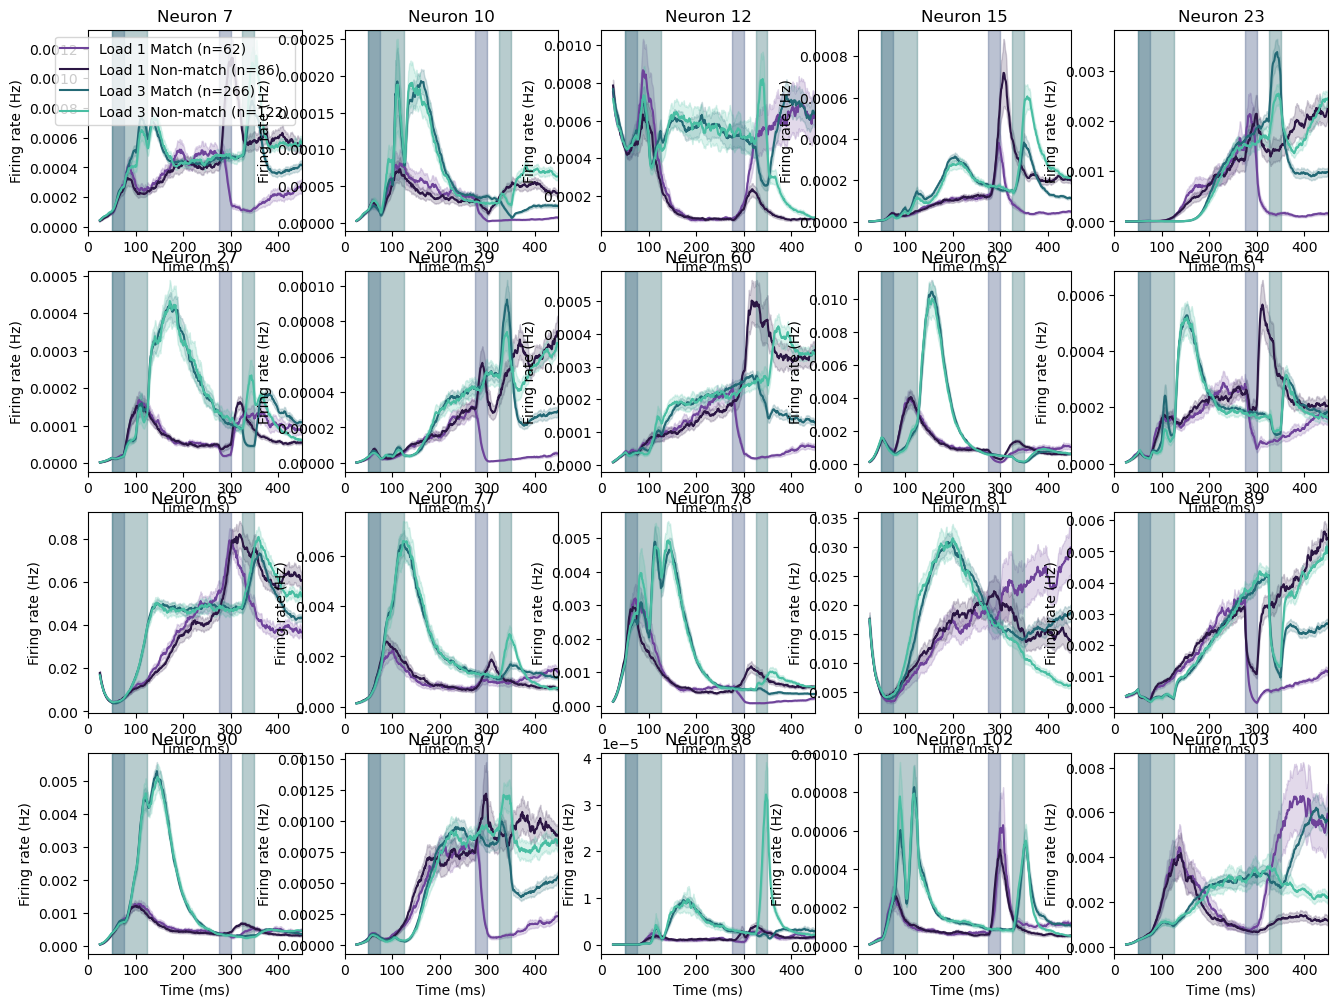

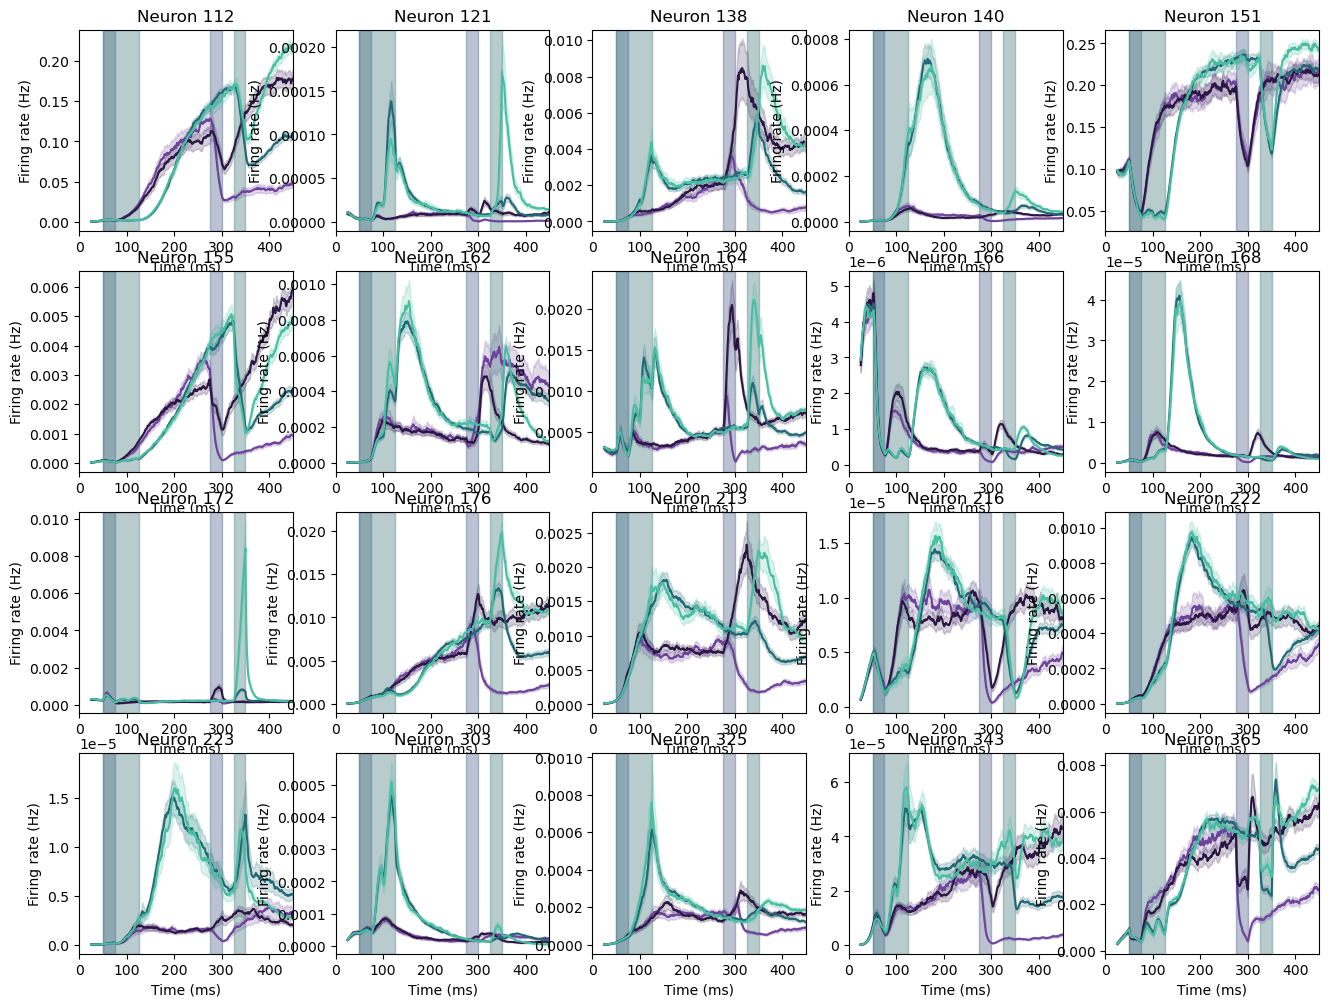

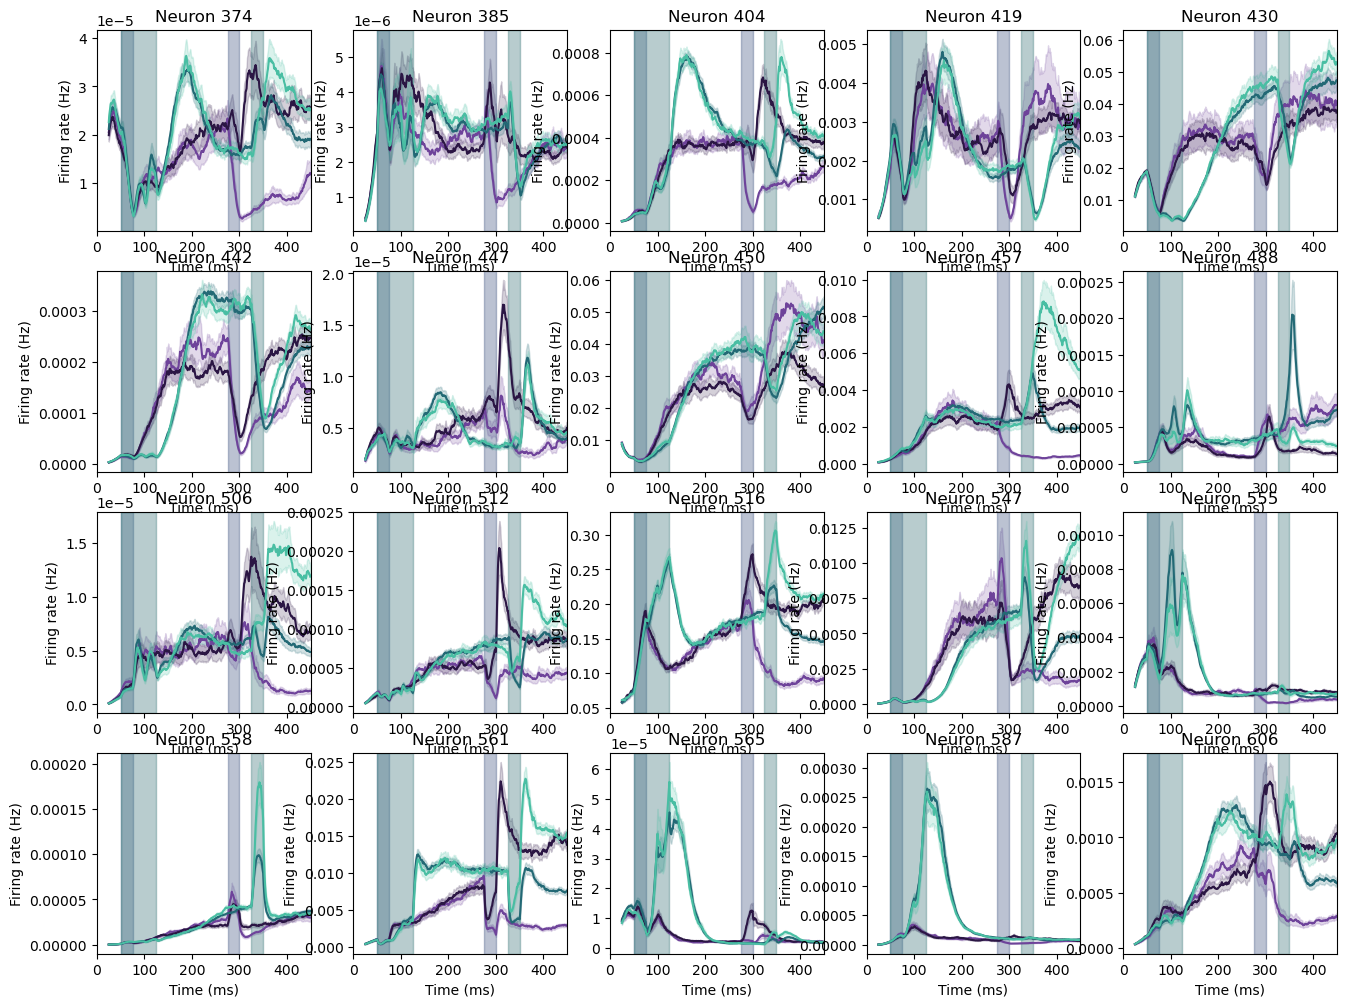

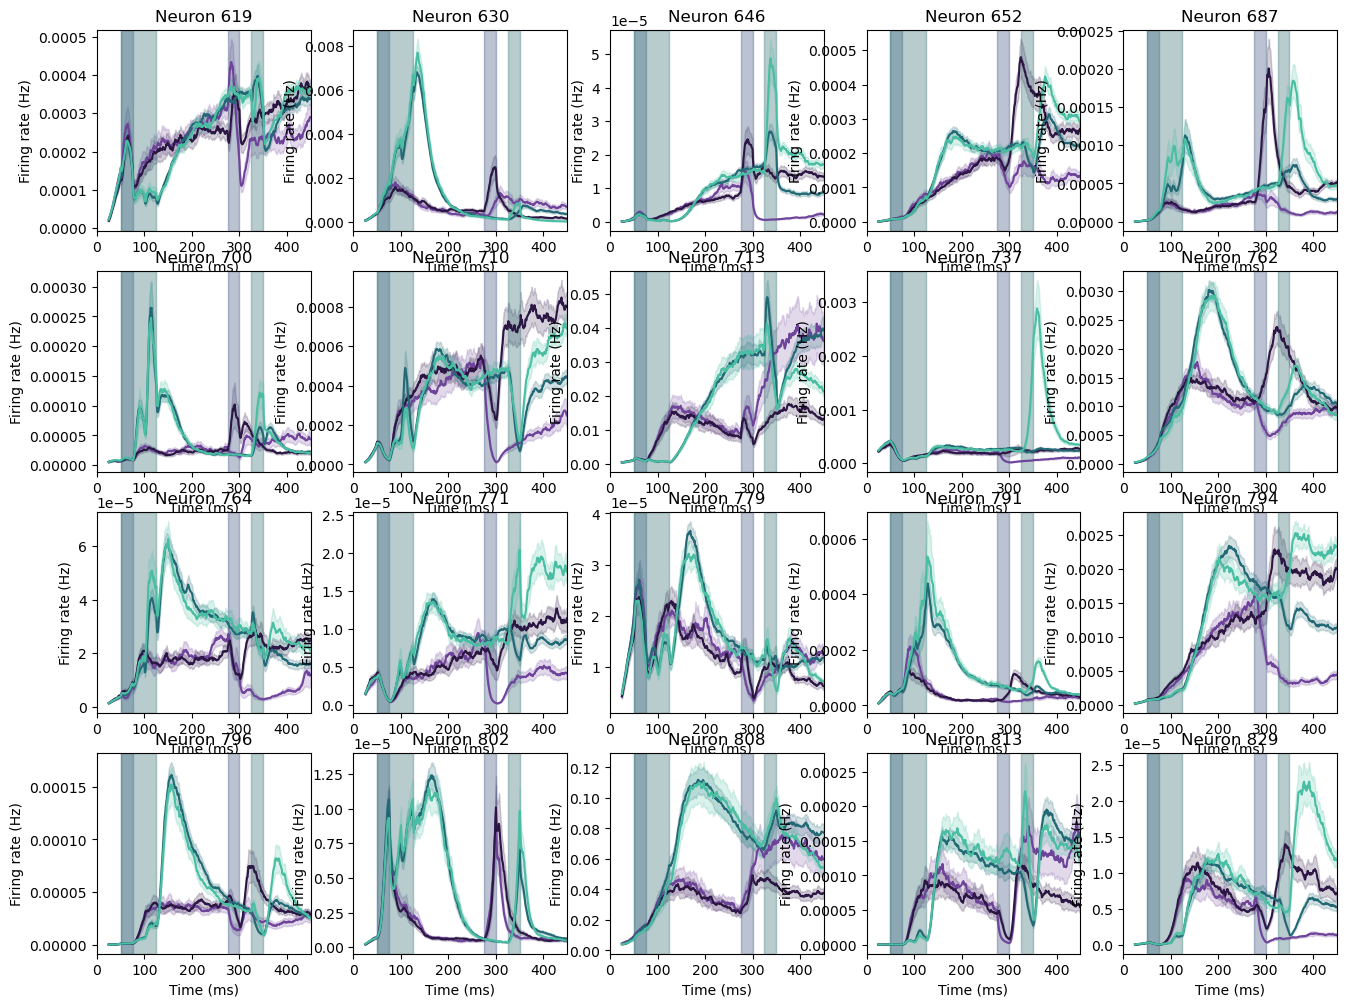

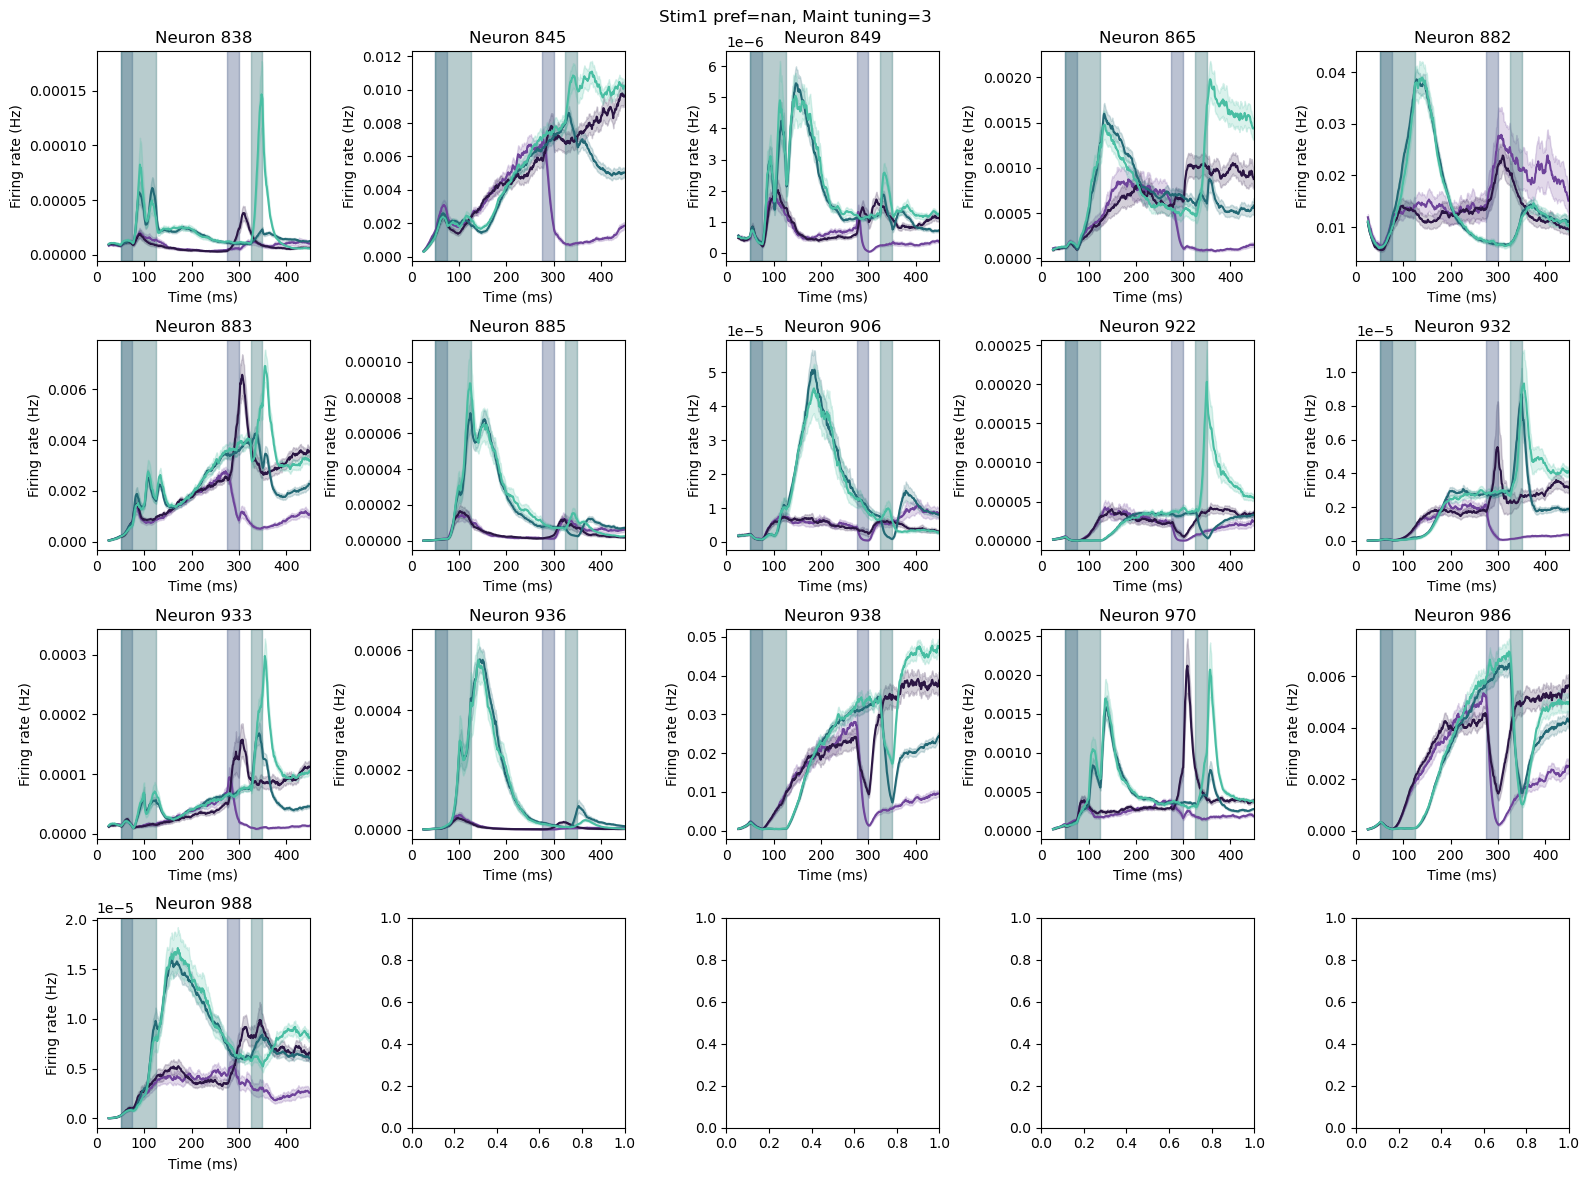

In [18]:
# let's start with neurons without tuning to stim1, pref load 1
importlib.reload(rn)

stim1_pref = np.nan
maint_pref = 3

if np.isnan(stim1_pref):
    stim1_tuned_neurons = np.where(np.isnan(stim1_tuning))[0] # no stim1 tuning
else:
    stim1_tuned_neurons = np.where(stim1_tuning == stim1_pref)[0]
if np.isnan(maint_pref):
    maint_tuned_neurons = np.where(np.isnan(load_tuning))[0] # no maintenance tuning
else:
    maint_tuned_neurons = np.where(load_tuning == maint_pref)[0]

# print(f'Neurons pref stim1={stim1_pref}: {len(stim1_tuned_neurons)}')
# print(f'Neurons pref maint={maint_pref}: {len(maint_tuned_neurons)}')

# for one of these neurons
neuron_idxs = np.intersect1d(stim1_tuned_neurons, maint_tuned_neurons)
print(f'Neurons that prefer stim1={stim1_pref} and maint={maint_pref}: {len(neuron_idxs)}')

for i_plot in range(len(neuron_idxs)):
    # make a new figure for each 20 neurons
    if i_plot % 20 == 0:
        fig, axs = plt.subplots(4, 5, figsize=(16,12))
        axs = axs.flatten()

    neuron_idx = neuron_idxs[i_plot]
    neuron_rates = rates_data[:, neuron_idx, :]
    neuron_rates[:, :25] = np.nan # mask the first 25 time bins to avoid noise; trials x time

    _, colors = rn.get_trialtype_colors()

    t_range = np.arange(rates_data.shape[2])
    
    nonpref_idx = np.where(np.all(trial_labels[:, 2:5] != stim1_pref, axis=1))[0]
    nonpref_load1_idx = np.intersect1d(nonpref_idx, np.where(trial_labels[:, 0] == 1)[0])
    nonpref_load3_idx = np.intersect1d(nonpref_idx, np.where(trial_labels[:, 0] == 3)[0])

    # stim1=nonpreferred, stim2=match vs non-match (only load 1 and 3)
    nonpref_load1_idx_match = np.intersect1d(nonpref_load1_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    nonpref_load1_idx_nonmatch = np.intersect1d(nonpref_load1_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    nonpref_load3_idx_match = np.intersect1d(nonpref_load3_idx, np.where(trial_labels[:, 1] == 1)[0]) # match trials
    nonpref_load3_idx_nonmatch = np.intersect1d(nonpref_load3_idx, np.where(trial_labels[:, 1] == -1)[0]) # non-match trials
    rn.plot_rates(neuron_rates, nonpref_load1_idx_match, nonpref_load1_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 1 Match', labels_two='Load 1 Non-match', colors=[colors[0],colors[1]], ax=axs[i_plot%20],
                  title='Non-Pref Stim: Match/Non-match')
    rn.plot_rates(neuron_rates, nonpref_load3_idx_match, nonpref_load3_idx_nonmatch, settings, trial_labels,
                  labels_one='Load 3 Match', labels_two='Load 3 Non-match', colors=[colors[2],colors[3]], ax=axs[i_plot%20],
                  title='Non-Pref Stim: Match/Non-match')
    
    # turn off legend if i_plot > 0 to avoid repetition
    if i_plot > 0:
        axs[i_plot%20].legend_.remove()
    
    axs[i_plot%20].set_title(f'Neuron {neuron_idx}')

plt.suptitle(f'Stim1 pref={stim1_pref}, Maint tuning={maint_pref}')
plt.tight_layout()
plt.show()